In [1]:
# Install compatible TensorFlow and tensorflow-privacy(sol)
# !pip uninstall tensorflow -y
# !pip uninstall tensorflow-privacy -y 
# !pip install tensorflow==2.14.0
# !pip install tensorflow-privacy==0.8.0

In [20]:
# =========================
# Standard Library
# =========================
import os
import random
import time
import warnings
import multiprocessing

# =========================
# Third-Party: Numerical / Data
# =========================
import numpy as np
import pandas as pd

# =========================
# Third-Party: Visualization
# =========================
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# Third-Party: sklearn
# =========================
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.utils import resample, shuffle
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    auc,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_curve,
    roc_auc_score,
)

# =========================
# Third-Party: Imbalanced-Learn
# =========================
from imblearn.over_sampling import RandomOverSampler

# =========================
# Third-Party: TensorFlow & Privacy
# =========================
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout,
    Flatten,
    Conv2D,
    MaxPooling2D,
)
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.metrics import (
    TruePositives,
    TrueNegatives,
    FalsePositives,
    FalseNegatives,
)


# !pip install tensorflow-privacy==0.8.12
import tensorflow_privacy

from tensorflow_privacy.privacy.analysis import compute_dp_sgd_privacy

# =========================
# Third-Party: Genetic Algorithm (DEAP)
# =========================
from deap import base, creator, tools

# 
import copy
toolbox.register("clone", copy.deepcopy)

# =========================
# Warnings
# =========================
warnings.filterwarnings("ignore", category=UserWarning)
tf.get_logger().setLevel("ERROR")


In [21]:
data  = pd.read_csv(r"C:\Users\dmachooka\Downloads\dmac\data.csv")

In [22]:
data.head(2)

,timestamp,src_ip,dst_ip,protocol,ttl,ip_len,ip_flag_df,ip_flag_mf,ip_flag_rb,src_port,...,tcp_flag_ns,tcp_flag_cwr,tcp_flag_ecn,tcp_flag_urg,tcp_flag_ack,tcp_flag_push,tcp_flag_reset,tcp_flag_syn,tcp_flag_fin,is_attack
0,"02/14/2020, 11:01:47:599181",1,18,12,26,118,1,0,0,14816,...,0,0,0,0,2,2,0,0,2,0
1,"02/14/2020, 10:53:58:393457",5,18,12,26,118,1,0,0,27432,...,0,0,0,0,2,2,0,0,2,0


In [23]:
data.isna().sum()

timestamp         0
src_ip            0
dst_ip            0
protocol          0
ttl               0
ip_len            0
ip_flag_df        0
ip_flag_mf        0
ip_flag_rb        0
src_port          0
dst_port          0
tcp_flag_res      0
tcp_flag_ns       0
tcp_flag_cwr      0
tcp_flag_ecn      0
tcp_flag_urg      0
tcp_flag_ack      0
tcp_flag_push     0
tcp_flag_reset    0
tcp_flag_syn      0
tcp_flag_fin      0
is_attack         0
dtype: int64

In [24]:
data.columns

Index(['timestamp', 'src_ip', 'dst_ip', 'protocol', 'ttl', 'ip_len',
       'ip_flag_df', 'ip_flag_mf', 'ip_flag_rb', 'src_port', 'dst_port',
       'tcp_flag_res', 'tcp_flag_ns', 'tcp_flag_cwr', 'tcp_flag_ecn',
       'tcp_flag_urg', 'tcp_flag_ack', 'tcp_flag_push', 'tcp_flag_reset',
       'tcp_flag_syn', 'tcp_flag_fin', 'is_attack'],
      dtype='object')

In [25]:
try:
    data = data.drop('timestamp', axis=1)
except KeyError:
    pass

In [26]:
data.columns

Index(['src_ip', 'dst_ip', 'protocol', 'ttl', 'ip_len', 'ip_flag_df',
       'ip_flag_mf', 'ip_flag_rb', 'src_port', 'dst_port', 'tcp_flag_res',
       'tcp_flag_ns', 'tcp_flag_cwr', 'tcp_flag_ecn', 'tcp_flag_urg',
       'tcp_flag_ack', 'tcp_flag_push', 'tcp_flag_reset', 'tcp_flag_syn',
       'tcp_flag_fin', 'is_attack'],
      dtype='object')

In [27]:
target_column = 'is_attack'
categorical_columns = [col for col in data.columns if col not in [target_column]]

In [28]:
X = data.drop(target_column, axis=1)
y = data[target_column]

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.25, random_state=42)

X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.4, random_state=42)



# Standard Scaling
scaler = StandardScaler()

#Perfom feature scaling for the training set
X_train_scaled = X_train.copy()
X_train_scaled[categorical_columns] = scaler.fit_transform(X_train[categorical_columns])

#Perfom feature scaling for the training set
X_valid_scaled = X_valid.copy()
X_valid_scaled[categorical_columns] = scaler.transform(X_valid[categorical_columns])

#Perfom feature scaling for the test set
X_test_scaled = X_test.copy()
X_test_scaled[categorical_columns] = scaler.transform(X_test[categorical_columns])

# Reshape data for LSTM

#I now convert the scaled training set into a NP Arrays and then reshape it

#I reshaped it to be compatible with the expected inputs by LSTM model
X_train_numpy = X_train_scaled[categorical_columns].to_numpy()
X_train_lstm = X_train_numpy.reshape(X_train_numpy.shape[0], 1, X_train_numpy.shape[1])

In [29]:
# Function to plot loss curves
def plot_loss(history1, history2=None):
    plt.figure(figsize=(12, 4))

    # Plot training & validation loss values for the first model
    plt.subplot(1, 2, 1)
    plt.plot(history1.history['loss'])
    plt.plot(history1.history['val_loss'])
    plt.title('Model loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(['Train', 'Validation'], loc='upper right')

    # Plot training & validation accuracy values for the first model
    plt.subplot(1, 2, 2)
    plt.plot(history1.history['accuracy'])
    plt.plot(history1.history['val_accuracy'])
    plt.title('Model accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend(['Train', 'Validation'], loc='lower right')

    if history2 is not None:
        # Plot training & validation loss values for the second model
        plt.subplot(1, 2, 1)
        plt.plot(history2.history['loss'], linestyle='dashed')
        plt.plot(history2.history['val_loss'], linestyle='dashed')
        plt.legend(['Train', 'Validation', 'Train Privacy', 'Validation Privacy'], loc='upper right')

        # Plot training & validation accuracy values for the second model
        plt.subplot(1, 2, 2)
        plt.plot(history2.history['accuracy'], linestyle='dashed')
        plt.plot(history2.history['val_accuracy'], linestyle='dashed')
        plt.legend(['Train', 'Validation', 'Train Privacy', 'Validation Privacy'], loc='lower right')

    plt.tight_layout()
    plt.show()

## Privacy GA

In [30]:
# # --- Reduced parameter search space (CPU < 4 day) ---testing

# LSTM_UNITS = [32,64]              # keep small
# DENSE_UNITS = [32,64]

# ACTIVATIONS = ['relu', ]     # fewer activations
# OPTIMIZERS = ['adam']              # fastest convergence
# # LOSSES = ['categorical_crossentropy']
# LOSSES = ['binary_crossentropy']


# LEARNING_RATES = [0.001]           # single LR
# BATCH_SIZES = [64]                 # stable on CPU
# EPOCHS = [20, 30]                  # hard cap

# MAX_LSTM_LAYERS = 2                # limit depth
# MAX_DENSE_LAYERS = 2

# noise_multiplier = 1.1             # slightly reduced
# gene_alg = True

In [31]:
# # Ensure X_train_scaled and X_test_scaled are NumPy arrays
# if isinstance(X_train_scaled, pd.DataFrame):
#     X_train_scaled = X_train_scaled.to_numpy()
# if isinstance(X_test_scaled, pd.DataFrame):
#     X_test_scaled = X_test_scaled.to_numpy()

# # Ensure y is NumPy array
# if hasattr(y_train, 'to_numpy'):
#     y_train = y_train.to_numpy()
# if hasattr(y_test, 'to_numpy'):
#     y_test = y_test.to_numpy()

# # Force 3D shape for LSTM: (samples, 1, features)
# if X_train_scaled.ndim == 2:
#     X_train_scaled = X_train_scaled.reshape(X_train_scaled.shape[0], 1, X_train_scaled.shape[1])
# if X_test_scaled.ndim == 2:
#     X_test_scaled = X_test_scaled.reshape(X_test_scaled.shape[0], 1, X_test_scaled.shape[1])

# print("X_train_scaled shape:", X_train_scaled.shape)
# print("X_test_scaled shape: ", X_test_scaled.shape)


In [32]:
# # ---------------------------
# # Subsample for GA evaluation
# # ---------------------------
# subset_size = 50000  # adjust based on RAM/GPU
# np.random.seed(42)   # reproducibility

# if X_train_scaled.shape[0] > subset_size:
#     indices = np.random.choice(X_train_scaled.shape[0], subset_size, replace=False)
#     X_train_subset = X_train_scaled[indices]
#     y_train_subset = y_train[indices]
# else:
#     X_train_subset = X_train_scaled
#     y_train_subset = y_train
# # ensures fast GA evaluation

In [33]:
# # enables mixed precision GPU speed up
# from tensorflow.keras import mixed_precision

# policy = mixed_precision.Policy('mixed_float16')
# mixed_precision.set_global_policy(policy)
# print("Mixed precision enabled:", policy)


In [34]:
# # GA helper functions
# # import random
# # from deap import base, creator, tools
# # import tensorflow as tf
# # from tensorflow.keras.models import Sequential
# # from tensorflow.keras.layers import LSTM, Dense, Dropout
# # from tensorflow_privacy.privacy.analysis import compute_dp_sgd_privacy_lib
# # from sklearn.model_selection import StratifiedKFold
# # from sklearn.metrics import f1_score

# # -----------------------------
# # Repair dropouts
# # -----------------------------
# def repair(ind):
#     required = len(ind['lstm_units']) + len(ind['dense_units'])
#     if 'dropouts' not in ind or len(ind['dropouts']) != required:
#         ind['dropouts'] = [random.uniform(0.1, 0.5) for _ in range(required)]

# # -----------------------------
# # Custom crossover
# # -----------------------------
# def custom_crossover(ind1, ind2):
#     for key in ind1.keys():
#         if random.random() < 0.5:
#             ind1[key], ind2[key] = ind2[key], ind1[key]
#     repair(ind1)
#     repair(ind2)
#     return ind1, ind2

# # -----------------------------
# # Custom mutation
# # -----------------------------
# def custom_mutation(ind):
#     param_to_mutate = random.choice(list(ind.keys()))
#     if param_to_mutate == 'lstm_units':
#         ind['lstm_units'] = [random.choice(LSTM_UNITS) for _ in range(len(ind['lstm_units']))]
#     elif param_to_mutate == 'dense_units':
#         ind['dense_units'] = [random.choice(DENSE_UNITS) for _ in range(len(ind['dense_units']))]
#     elif param_to_mutate == 'activation':
#         ind['activation'] = random.choice(ACTIVATIONS)
#     elif param_to_mutate == 'optimizer':
#         ind['optimizer'] = random.choice(OPTIMIZERS)
#     elif param_to_mutate == 'loss':
#         ind['loss'] = random.choice(LOSSES)
#     elif param_to_mutate == 'learning_rate':
#         ind['learning_rate'] = random.choice(LEARNING_RATES)
#     elif param_to_mutate == 'batch_size':
#         ind['batch_size'] = random.choice(BATCH_SIZES)
#     elif param_to_mutate == 'epochs':
#         ind['epochs'] = random.choice([5, 10])  # fewer epochs for GA
#     elif param_to_mutate == 'dropouts':
#         ind['dropouts'] = [random.uniform(0.1, 0.5) for _ in range(len(ind['lstm_units']) + len(ind['dense_units']))]
#     return (ind,)


In [35]:
# # evaluate GA fitness
# from tensorflow.keras.callbacks import EarlyStopping

# def evaluate_nn(hyperparams):
#     lstm_units = hyperparams['lstm_units']
#     dense_units = hyperparams['dense_units']
#     activation  = hyperparams['activation']
#     learning_rate = hyperparams['learning_rate']
#     batch_size = hyperparams['batch_size']
#     epochs = hyperparams['epochs']
#     dropouts = hyperparams['dropouts']
    
#     model = Sequential()
    
#     # LSTM layers
#     for i, units in enumerate(lstm_units):
#         return_sequences = (i < len(lstm_units) - 1)
#         if i == 0:
#             model.add(LSTM(units, activation=activation,
#                            return_sequences=return_sequences,
#                            input_shape=(X_train_subset.shape[1], X_train_subset.shape[2])))
#         else:
#             model.add(LSTM(units, activation=activation, return_sequences=return_sequences))
#         model.add(Dropout(dropouts[i]))
    
#     # Dense layers
#     for j, units in enumerate(dense_units):
#         model.add(Dense(units, activation=activation))
#         model.add(Dropout(dropouts[len(lstm_units)+j]))
    
#     # Output
#     model.add(Dense(2, activation='softmax'))
    
#     # DP optimizer
#     dp_optimizer = tensorflow_privacy.DPKerasSGDOptimizer(
#         l2_norm_clip=1.0,
#         noise_multiplier=noise_multiplier,
#         num_microbatches=1,
#         learning_rate=learning_rate
#     )
    
#     model.compile(optimizer=dp_optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    
#     # Early stopping
#     early_stop = EarlyStopping(monitor='loss', patience=3, restore_best_weights=True)
    
#     # 1-fold CV (fast)
#     kfold = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)
#     cv_results = []
    
#     for train_idx, val_idx in kfold.split(X_train_subset, y_train_subset):
#         X_train_fold = X_train_subset[train_idx]
#         X_val_fold   = X_train_subset[val_idx]
#         y_train_fold = tf.keras.utils.to_categorical(y_train_subset[train_idx], num_classes=2)
#         y_val_fold   = tf.keras.utils.to_categorical(y_train_subset[val_idx], num_classes=2)
        
#         model.fit(X_train_fold, y_train_fold, epochs=epochs, batch_size=batch_size,
#                   verbose=0, callbacks=[early_stop])
        
#         y_pred_proba = model.predict(X_val_fold, verbose=0)
#         y_pred = np.argmax(y_pred_proba, axis=1)
#         y_true = np.argmax(y_val_fold, axis=1)
        
#         f1 = f1_score(y_true, y_pred, average="binary")
#         cv_results.append(f1)
    
#     # DP epsilon estimate
#     try:
#         privacy_report = compute_dp_sgd_privacy_lib.compute_dp_sgd_privacy_statement(
#             n=X_train_scaled.shape[0],
#             batch_size=batch_size,
#             noise_multiplier=noise_multiplier,
#             epochs=epochs,
#             delta=1e-5
#         )
#         epsilon = getattr(privacy_report, "epsilon", None)
#         if epsilon is None:
#             epsilon = float(str(privacy_report).split("epsilon=")[1].split()[0])
#     except Exception:
#         epsilon = 0.0
    
#     score = np.mean(cv_results) - epsilon  # GA maximizes score
#     return (score,)


In [36]:
# # DEAP GA setup
# creator.create("FitnessMax", base.Fitness, weights=(1.0,))
# creator.create("Individual", dict, fitness=creator.FitnessMax)

# toolbox = base.Toolbox()
# toolbox.register("individual", tools.initIterate, creator.Individual, create_hyperparameter_set)
# toolbox.register("population", tools.initRepeat, list, toolbox.individual)
# toolbox.register("mate", custom_crossover)
# toolbox.register("mutate", custom_mutation)
# toolbox.register("select", tools.selTournament, tournsize=3)
# toolbox.register("evaluate", evaluate_nn)


In [37]:
# # optimized GA test
# def genetic_algorithm():
#     pop = toolbox.population(n=10)  # small population for fast test
#     ngen = 5  # fewer generations
#     cxpb, mutpb = 0.5, 0.2

#     for gen in range(ngen):
#         print(f"-- Generation {gen} --")
#         fitnesses = list(map(toolbox.evaluate, pop))
#         for ind, fit in zip(pop, fitnesses):
#             ind.fitness.values = fit
        
#         offspring = toolbox.select(pop, len(pop))
#         offspring = list(map(toolbox.clone, offspring))
        
#         for child1, child2 in zip(offspring[::2], offspring[1::2]):
#             if random.random() < cxpb:
#                 toolbox.mate(child1, child2)
#                 del child1.fitness.values
#                 del child2.fitness.values
        
#         for mutant in offspring:
#             if random.random() < mutpb:
#                 toolbox.mutate(mutant)
#                 del mutant.fitness.values
        
#         # Evaluate invalid fitness
#         invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
#         fitnesses = map(toolbox.evaluate, invalid_ind)
#         for ind, fit in zip(invalid_ind, fitnesses):
#             ind.fitness.values = fit

#         pop[:] = offspring

#     top_ind = tools.selBest(pop, 1)[0]
#     return top_ind

# best_hyperparameters = genetic_algorithm()
# print("Best Hyperparameters found by GA:", best_hyperparameters)


In [38]:
# Best Hyperparameters found by GA: {'lstm_units': [32], 'dense_units': [64, 64, 256], 'activation': 'relu', 'optimizer': 'sgd', 'loss': 'binary_crossentropy', 'learning_rate': 0.0001, 'batch_size': 256, 'epochs': 20, 'dropouts': [0.12853747837450935, 0.4560394478511045, 0.28159558670410034, 0.23296270317580597]}

In [39]:
# # --- Define parameter search space ---full search space two months plus
# LSTM_UNITS = [16, 32, 64, 128, 256]
# DENSE_UNITS = [16, 32, 64, 128, 256]
# ACTIVATIONS = ['gelu', 'swish', 'silu', 'relu']
# OPTIMIZERS = ['sgd', 'adam']
# LOSSES = ['binary_crossentropy']
# LEARNING_RATES = [0.001, 0.0001]
# BATCH_SIZES = [64, 128, 256]
# EPOCHS = [20, 30, 50, 100]
# MAX_LSTM_LAYERS = 3
# MAX_DENSE_LAYERS = 4
# noise_multiplier=1.3
# gene_alg = True

In [40]:
# def evaluate_nn(hyperparams):
#     lstm_units = hyperparams['lstm_units']
#     dense_units = hyperparams['dense_units']
#     activation = hyperparams['activation']
#     optimizer_choice = hyperparams['optimizer']
#     loss_choice = hyperparams['loss']
#     learning_rate = hyperparams['learning_rate']
#     batch_size = hyperparams['batch_size']
#     epochs = hyperparams['epochs']
#     dropouts = hyperparams['dropouts']

#     # Build model
#     model = Sequential()

#     # Add LSTM layers
#     for i, units in enumerate(lstm_units):
#         return_sequences = (i < len(lstm_units) - 1)
#         model.add(LSTM(
#             units=units,
#             activation=activation,
#             return_sequences=return_sequences,
#             input_shape=(len(categorical_columns), 1)   # if i == 0 else None---------------------------------------------------------------
#         ))
#         model.add(Dropout(rate=dropouts[i]))

#     # Add Dense layers
#     for j, units in enumerate(dense_units):
#         model.add(Dense(units=units, activation=activation))
#         #  can be replaced before j len(lstm_units) + 
#         model.add(Dropout(rate=dropouts[j]))

#     # Output layer (binary classification)
#     model.add(Dense(2, activation='softmax'))

#     # DP optimizer
#     dp_optimizer = tensorflow_privacy.DPKerasSGDOptimizer(
#         l2_norm_clip=1.0,
#         noise_multiplier=1.3,
#         num_microbatches=1,
#         learning_rate=learning_rate
#     )

#     model.compile(optimizer=dp_optimizer, loss=loss_choice, metrics=['accuracy'])

#     # Cross-validation
#     kfold = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)
#     cv_results = []

#     scaler = StandardScaler()
#     X_train_scaled = scaler.fit_transform(X_train)

#     X_train_scaled = pd.DataFrame(
#     X_train_scaled,
#     columns=X_train.columns,
#     index=X_train.index
#     )



    
#     for train_index, test_index in kfold.split(X_train_scaled[categorical_columns], y_train):
#         X_train_fold = X_train_scaled[categorical_columns].iloc[train_index].values.reshape(-1, len(categorical_columns), 1)
#         X_val_fold = X_train_scaled[categorical_columns].iloc[test_index].values.reshape(-1, len(categorical_columns), 1)
#         y_train_fold = tf.keras.utils.to_categorical(y_train.iloc[train_index], num_classes=2)
#         y_val_fold = tf.keras.utils.to_categorical(y_train.iloc[test_index], num_classes=2)

#         model.fit(X_train_fold, y_train_fold,
#                   epochs=epochs, batch_size=batch_size, verbose=0)
#         # _, val_accuracy = model.evaluate(X_val_fold, y_val_fold, verbose=0)
#         # cv_results.append(val_accuracy)
#         # Predict class labels for F1
#         y_pred_proba = model.predict(X_val_fold, verbose=0)
#         y_pred = np.argmax(y_pred_proba, axis=1)   # convert softmax → class

#         y_pred = np.argmax(y_pred_proba, axis=1)
#         y_true = np.argmax(y_val_fold, axis=1) 
        
#         # Compute F1
#         f1 = f1_score(y_true, y_pred, average="binary")  # or "macro", "weighted"
#         cv_results.append(f1)

#     # Extract trainable variables from the model
#     trainable_variables = model.trainable_variables

#     # Compute privacy budget /compute_dp_sgd_privacy.compute_dp_sgd_privacy_lib.compute_dp_sgd_privacy_statement
#     privacy_report = compute_dp_sgd_privacy.compute_dp_sgd_privacy_lib.compute_dp_sgd_privacy_statement(
#         number_of_examples=len(X_train_scaled),
#         batch_size=batch_size,
#         noise_multiplier=1.3,
#         num_epochs=epochs,
#         delta=1e-5
#     )

#     epsilon = None

#     # Case A: report is an object with epsilon attr
#     if hasattr(privacy_report, "epsilon"):
#         epsilon = privacy_report.epsilon

#     # Case B: report is a tuple (epsilon, something)
#     elif isinstance(privacy_report, tuple) and len(privacy_report) >= 1 and isinstance(privacy_report[0], (float, int)):
#         epsilon = privacy_report[0]

#     # Case C: report is a string
#     elif isinstance(privacy_report, str):
#         import re
#         match = re.search(r"epsilon[^0-9]*([0-9.]+)", privacy_report.lower())
#         if match:
#             epsilon = float(match.group(1))

#     score = np.mean(cv_results) - epsilon # GA maximizes score by default

#     return (score,)

In [41]:
# def custom_crossover(ind1, ind2):
#     """
#     Safe crossover for dict-based individuals.
#     Swaps values by key, never by index.
#     """
#     for key in ind1.keys():
#         if random.random() < 0.5:
#             ind1[key], ind2[key] = ind2[key], ind1[key]

#     repair(ind1)
#     repair(ind2)
#     return ind1, ind2

    
# def repair(ind):
#     """
#     Ensures dropouts length matches architecture depth
#     """
#     required = len(ind['lstm_units']) + len(ind['dense_units'])

#     if 'dropouts' not in ind or len(ind['dropouts']) != required:
#         ind['dropouts'] = [random.uniform(0.1, 0.5) for _ in range(required)]
    

# def custom_mutation(ind):
#     param_to_mutate = random.choice(list(ind.keys()))

#     if param_to_mutate == 'lstm_units':
#         ind['lstm_units'] = [random.choice(LSTM_UNITS) for _ in range(len(ind['lstm_units']))]
#     elif param_to_mutate == 'lstm_dropouts':
#         ind['lstm_dropouts'] = [random.uniform(0.1, 0.5) for _ in range(len(ind['lstm_dropouts']))]
#     elif param_to_mutate == 'dense_units':
#         ind['dense_units'] = [random.choice(DENSE_UNITS) for _ in range(len(ind['dense_units']))]
#     elif param_to_mutate == 'dense_dropouts':
#         ind['dense_dropouts'] = [random.uniform(0.1, 0.5) for _ in range(len(ind['dense_dropouts']))]
#     elif param_to_mutate == 'activation':
#         ind['activation'] = random.choice(ACTIVATIONS)
#     elif param_to_mutate == 'optimizer':
#         ind['optimizer'] = random.choice(OPTIMIZERS)
#     elif param_to_mutate == 'loss':
#         ind['loss'] = random.choice(LOSSES)
#     elif param_to_mutate == 'learning_rate':
#         ind['learning_rate'] = random.choice(LEARNING_RATES)
#     elif param_to_mutate == 'batch_size':
#         ind['batch_size'] = random.choice(BATCH_SIZES)
#     elif param_to_mutate == 'epochs':
#         ind['epochs'] = random.choice(EPOCHS)

#     return (ind,)

In [42]:
# def create_hyperparameter_set():
#     n_lstm = random.randint(1, MAX_LSTM_LAYERS)
#     n_dense = random.randint(1, MAX_DENSE_LAYERS)
#     return {
#         'lstm_units': [random.choice(LSTM_UNITS) for _ in range(n_lstm)],
#         'dense_units': [random.choice(DENSE_UNITS) for _ in range(n_dense)],
#         'activation': random.choice(ACTIVATIONS),
#         'optimizer': random.choice(OPTIMIZERS),
#         'loss': random.choice(LOSSES),
#         'learning_rate': random.choice(LEARNING_RATES),
#         'batch_size': random.choice(BATCH_SIZES),
#         'epochs': random.choice(EPOCHS),
#         'dropouts': [random.uniform(0.1, 0.5) for _ in range(n_lstm + n_dense)]
#     }

# # === DEAP Setup ===


In [43]:
# creator.create("FitnessMax", base.Fitness, weights=(1.0,))
# creator.create("Individual", dict, fitness=creator.FitnessMax)

# toolbox = base.Toolbox()
# toolbox.register("individual", tools.initIterate, creator.Individual, create_hyperparameter_set)
# toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# toolbox.register("mate", custom_crossover)

# toolbox.register("mutate", tools.mutUniformInt, low=64, up=256, indpb=0.2)
# toolbox.register("select", tools.selTournament, tournsize=3)
# toolbox.register("evaluate", evaluate_nn)
# toolbox.register("batch_size", random.choice, BATCH_SIZES)

In [44]:
# def genetic_algorithm():
#     pop = toolbox.population(n=10)
#     ngen = 5  # Number of generations
#     cxpb, mutpb = 0.5, 0.2  # Crossover and mutation probabilities

#     for gen in range(ngen):
#         print(f"-- Generation {gen} --")

#         # Evaluate all individuals
#         fitnesses = list(map(toolbox.evaluate, pop))
#         for ind, fit in zip(pop, fitnesses):
#             ind.fitness.values = fit

#         # Select individuals for the next generation
#         offspring = toolbox.select(pop, len(pop))
#         offspring = list(map(toolbox.clone, offspring))

#         # Apply crossover and mutation on the offspring
#         for child1, child2 in zip(offspring[::2], offspring[1::2]):
#             if random.random() < cxpb:
#                 toolbox.mate(child1, child2)
#                 del child1.fitness.values
#                 del child2.fitness.values

#         for mutant in offspring:
#             if random.random() < mutpb:
#                 toolbox.mutate(mutant)
#                 del mutant.fitness.values

#         # Evaluate the individuals with an invalid fitness
#         invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
#         fitnesses = map(toolbox.evaluate, invalid_ind)
#         for ind, fit in zip(invalid_ind, fitnesses):
#             ind.fitness.values = fit

#         pop[:] = offspring

#     # Return the best individual
#     top_individual = tools.selBest(pop, 1)[0]
#     return top_individual

In [45]:
# dir(compute_dp_sgd_privacy)

In [46]:
# best_hyperparameters = genetic_algorithm()
# print("Best Hyperparameters:", best_hyperparameters)

In [47]:
# test case

In [48]:
# search space
LSTM_UNITS = [16, 32, 64, 128, 256]
DENSE_UNITS = [16, 32, 64, 128, 256]
ACTIVATIONS = ['relu', 'gelu', 'swish', 'silu']
OPTIMIZERS = ['sgd', 'adam']
LOSSES = ['binary_crossentropy']
LEARNING_RATES = [0.001, 0.0001]
BATCH_SIZES = [64, 128, 256]
EPOCHS = [20, 30, 50]
MAX_LSTM_LAYERS = 3
MAX_DENSE_LAYERS = 4
noise_multiplier = 1.3

In [49]:
# hyperparameter generation

In [50]:
def create_hyperparameter_set():
    n_lstm = random.randint(1, MAX_LSTM_LAYERS)
    n_dense = random.randint(1, MAX_DENSE_LAYERS)

    return {
        'lstm_units': [random.choice(LSTM_UNITS) for _ in range(n_lstm)],
        'dense_units': [random.choice(DENSE_UNITS) for _ in range(n_dense)],
        'activation': random.choice(ACTIVATIONS),
        'optimizer': random.choice(OPTIMIZERS),
        'loss': random.choice(LOSSES),
        'learning_rate': random.choice(LEARNING_RATES),
        'batch_size': random.choice(BATCH_SIZES),
        'epochs': random.choice(EPOCHS),
        'dropouts': [random.uniform(0.1, 0.5) for _ in range(n_lstm + n_dense)]
    }

In [51]:
# repair function

In [52]:
def repair(ind):
    required = len(ind['lstm_units']) + len(ind['dense_units'])

    if 'dropouts' not in ind or len(ind['dropouts']) != required:
        ind['dropouts'] = [random.uniform(0.1, 0.5) for _ in range(required)]

In [53]:
# custom crossover

In [54]:
def custom_crossover(ind1, ind2):
    for key in list(ind1.keys()):
        if key in ind2 and random.random() < 0.5:
            ind1[key], ind2[key] = ind2[key], ind1[key]

    repair(ind1)
    repair(ind2)
    return ind1, ind2

In [55]:
# custom mutation

In [56]:
def custom_mutation(ind):
    param = random.choice(list(ind.keys()))

    if param == 'lstm_units':
        ind['lstm_units'] = [random.choice(LSTM_UNITS)
                             for _ in range(len(ind['lstm_units']))]

    elif param == 'dense_units':
        ind['dense_units'] = [random.choice(DENSE_UNITS)
                              for _ in range(len(ind['dense_units']))]

    elif param == 'activation':
        ind['activation'] = random.choice(ACTIVATIONS)

    elif param == 'optimizer':
        ind['optimizer'] = random.choice(OPTIMIZERS)

    elif param == 'learning_rate':
        ind['learning_rate'] = random.choice(LEARNING_RATES)

    elif param == 'batch_size':
        ind['batch_size'] = random.choice(BATCH_SIZES)

    elif param == 'epochs':
        ind['epochs'] = random.choice(EPOCHS)

    repair(ind)
    return (ind,)

In [57]:
# evalutaion function

In [58]:
 def evaluate_nn(hyperparams):
    lstm_units = hyperparams['lstm_units']
    dense_units = hyperparams['dense_units']
    activation = hyperparams['activation']
    optimizer_choice = hyperparams['optimizer']
    loss_choice = hyperparams['loss']
    learning_rate = hyperparams['learning_rate']
    batch_size = hyperparams['batch_size']
    epochs = hyperparams['epochs']
    dropouts = hyperparams['dropouts']

    # Build model
    model = Sequential()

    # Add LSTM layers
    for i, units in enumerate(lstm_units):
        return_sequences = (i < len(lstm_units) - 1)
        model.add(LSTM(
            units=units,
            activation=activation,
            return_sequences=return_sequences,
            input_shape=(len(categorical_columns), 1)   # if i == 0 else None---------------------------------------------------------------
        ))
        model.add(Dropout(rate=dropouts[i]))

    # Add Dense layers
    for j, units in enumerate(dense_units):
        model.add(Dense(units=units, activation=activation))
        #  can be replaced before j len(lstm_units) + 
        model.add(Dropout(rate=dropouts[j]))

    # Output layer (binary classification)
    model.add(Dense(2, activation='softmax'))

    # DP optimizer
    dp_optimizer = tensorflow_privacy.DPKerasSGDOptimizer(
        l2_norm_clip=1.0,
        noise_multiplier=1.3,
        num_microbatches=1,
        learning_rate=learning_rate
    )

    model.compile(optimizer=dp_optimizer, loss=loss_choice, metrics=['accuracy'])

    # Cross-validation
    kfold = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)
    cv_results = []

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)

    X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
    )



    
    for train_index, test_index in kfold.split(X_train_scaled[categorical_columns], y_train):
        X_train_fold = X_train_scaled[categorical_columns].iloc[train_index].values.reshape(-1, len(categorical_columns), 1)
        X_val_fold = X_train_scaled[categorical_columns].iloc[test_index].values.reshape(-1, len(categorical_columns), 1)
        y_train_fold = tf.keras.utils.to_categorical(y_train.iloc[train_index], num_classes=2)
        y_val_fold = tf.keras.utils.to_categorical(y_train.iloc[test_index], num_classes=2)

        model.fit(X_train_fold, y_train_fold,
                  epochs=epochs, batch_size=batch_size, verbose=0)
        # _, val_accuracy = model.evaluate(X_val_fold, y_val_fold, verbose=0)
        # cv_results.append(val_accuracy)
        # Predict class labels for F1
        y_pred_proba = model.predict(X_val_fold, verbose=0)
        y_pred = np.argmax(y_pred_proba, axis=1)   # convert softmax → class

        y_pred = np.argmax(y_pred_proba, axis=1)
        y_true = np.argmax(y_val_fold, axis=1) 
        
        # Compute F1
        f1 = f1_score(y_true, y_pred, average="binary")  # or "macro", "weighted"
        cv_results.append(f1)

    # Extract trainable variables from the model
    trainable_variables = model.trainable_variables

    # Compute privacy budget /compute_dp_sgd_privacy.compute_dp_sgd_privacy_lib.compute_dp_sgd_privacy_statement
    privacy_report = compute_dp_sgd_privacy.compute_dp_sgd_privacy_lib.compute_dp_sgd_privacy_statement(
        number_of_examples=len(X_train_scaled),
        batch_size=batch_size,
        noise_multiplier=1.3,
        num_epochs=epochs,
        delta=1e-5
    )

    epsilon = None

    # Case A: report is an object with epsilon attr
    if hasattr(privacy_report, "epsilon"):
        epsilon = privacy_report.epsilon

    # Case B: report is a tuple (epsilon, something)
    elif isinstance(privacy_report, tuple) and len(privacy_report) >= 1 and isinstance(privacy_report[0], (float, int)):
        epsilon = privacy_report[0]

    # Case C: report is a string
    elif isinstance(privacy_report, str):
        import re
        match = re.search(r"epsilon[^0-9]*([0-9.]+)", privacy_report.lower())
        if match:
            epsilon = float(match.group(1))

    score = np.mean(cv_results) - epsilon # GA maximizes score by default

    return (score,)

In [59]:
# deap setup

In [60]:
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", dict, fitness=creator.FitnessMax)

toolbox = base.Toolbox()
toolbox.register("individual", tools.initIterate,
                 creator.Individual, create_hyperparameter_set)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

toolbox.register("mate", custom_crossover)
toolbox.register("mutate", custom_mutation)   # ✅ FIXED
toolbox.register("select", tools.selTournament, tournsize=3)
toolbox.register("evaluate", evaluate_nn)

C:\Users\dmachooka\AppData\Local\anaconda3\envs\tprivacy\lib\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'FitnessMax' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
C:\Users\dmachooka\AppData\Local\anaconda3\envs\tprivacy\lib\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


In [61]:
# genetic algorithm

In [62]:
def genetic_algorithm():

    pop = toolbox.population(n=10)
    ngen = 5
    cxpb, mutpb = 0.5, 0.2

    for gen in range(ngen):
        print(f"Generation {gen}")

        fitnesses = list(map(toolbox.evaluate, pop))
        for ind, fit in zip(pop, fitnesses):
            ind.fitness.values = fit

        offspring = toolbox.select(pop, len(pop))
        offspring = list(map(toolbox.clone, offspring))

        for child1, child2 in zip(offspring[::2], offspring[1::2]):
            if random.random() < cxpb:
                toolbox.mate(child1, child2)
                del child1.fitness.values
                del child2.fitness.values

        for mutant in offspring:
            if random.random() < mutpb:
                toolbox.mutate(mutant)
                del mutant.fitness.values

        invalid = [ind for ind in offspring if not ind.fitness.valid]
        fitnesses = map(toolbox.evaluate, invalid)
        for ind, fit in zip(invalid, fitnesses):
            ind.fitness.values = fit

        pop[:] = offspring

    return tools.selBest(pop, 1)[0]

In [63]:
# run GA/or not
best_hyperparameters = False

In [64]:
best_hyperparameters = genetic_algorithm()
print("Best Hyperparameters:", best_hyperparameters)

Generation 0
Generation 1
Generation 2
Generation 3
Generation 4
Best Hyperparameters: {'lstm_units': [32, 16], 'dense_units': [16, 128, 64], 'activation': 'relu', 'optimizer': 'sgd', 'loss': 'binary_crossentropy', 'learning_rate': 0.001, 'batch_size': 256, 'epochs': 20, 'dropouts': [0.3653204173027381, 0.11863341845183575, 0.35259343259178844, 0.2967955916968327, 0.40351423702259903]}


In [ ]:
# Best Hyperparameters: {'lstm_units': [32, 16], 'dense_units': [16, 128, 64], 'activation': 'relu', 'optimizer': 'sgd', 'loss': 'binary_crossentropy', 'learning_rate': 0.001, 'batch_size': 256, 'epochs': 20, 'dropouts': [0.3653204173027381, 0.11863341845183575, 0.35259343259178844, 0.2967955916968327, 0.40351423702259903]}

In [101]:
# =============================================================================
# CELL 1: IMPORTS GA optimized privacy RDP
# =============================================================================
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import numpy as np
import matplotlib.pyplot as plt

# sklearn metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# Differential Privacy Optimizer
from tensorflow_privacy.privacy.optimizers.dp_optimizer_keras import DPKerasSGDOptimizer

# Correct import for privacy budget calculation (works in current tensorflow-privacy)
from tensorflow_privacy.privacy.analysis.compute_dp_sgd_privacy_lib import compute_dp_sgd_privacy

print("✅ All imports successful")
print("TensorFlow version:", tf.__version__)

✅ All imports successful
TensorFlow version: 2.14.0


In [102]:
# =============================================================================
# CELL 2: HYPERPARAMETERS after getting them from GA
# =============================================================================
best_hp = {
    'num_lstm_layers': 2,
    'lstm_units': [64, 32],
    'num_dense_layers': 3,
    'dense_units': [128, 64, 32],
    'activation': 'relu',
    'loss': 'categorical_crossentropy',
    'learning_rate': 0.001,
    'batch_size': 256,
    'epochs': 20,
    'dropouts': [0.3653, 0.1186, 0.3526, 0.2968, 0.4035]
}

print("✅ Hyperparameters loaded")

✅ Hyperparameters loaded


In [103]:
# =============================================================================
# CELL 3: RESHAPE DATA + BUILD MODEL (Fixed)
# =============================================================================
# Force conversion to numpy and float32
X_train_scaled = np.asarray(X_train_scaled, dtype=np.float32)
X_test_scaled  = np.asarray(X_test_scaled,  dtype=np.float32)

print("After conversion - X_train shape:", X_train_scaled.shape)
print("After conversion - X_test shape :", X_test_scaled.shape)

# Reshape to 3D for LSTM: (samples, timesteps=1, features)
if X_train_scaled.ndim == 2:
    timesteps = 1
    features = X_train_scaled.shape[1]
    X_train_scaled = X_train_scaled.reshape((X_train_scaled.shape[0], timesteps, features))
    X_test_scaled  = X_test_scaled.reshape((X_test_scaled.shape[0], timesteps, features))
    print(f"✅ Successfully reshaped to (samples, timesteps, features) = {X_train_scaled.shape}")
else:
    print("Data already has 3 dimensions.")

# Build the model
privacy_model = Sequential(name="DP_LSTM_Model")

# --- LSTM Layers ---
for i in range(best_hp['num_lstm_layers']):
    return_seq = (i < best_hp['num_lstm_layers'] - 1)
    units = best_hp['lstm_units'][i] if i < len(best_hp['lstm_units']) else best_hp['lstm_units'][-1]
    
    # Only pass input_shape to the FIRST layer
    if i == 0:
        lstm_layer = LSTM(
            units=units,
            activation=best_hp['activation'],
            return_sequences=return_seq,
            input_shape=(X_train_scaled.shape[1], X_train_scaled.shape[2])
        )
    else:
        lstm_layer = LSTM(
            units=units,
            activation=best_hp['activation'],
            return_sequences=return_seq
        )
    
    privacy_model.add(lstm_layer)
    
    if i < len(best_hp['dropouts']):
        privacy_model.add(Dropout(best_hp['dropouts'][i]))

# --- Dense Layers ---
for j in range(best_hp['num_dense_layers']):
    units = best_hp['dense_units'][j] if j < len(best_hp['dense_units']) else best_hp['dense_units'][-1]
    privacy_model.add(Dense(units=units, activation=best_hp['activation']))
    idx = j + best_hp['num_lstm_layers']
    if idx < len(best_hp['dropouts']):
        privacy_model.add(Dropout(best_hp['dropouts'][idx]))

# --- Output Layer ---
privacy_model.add(Dense(2, activation='softmax'))

privacy_model.summary()

After conversion - X_train shape: (1544371, 1, 20)
After conversion - X_test shape : (205917, 1, 20)
Data already has 3 dimensions.
Model: "DP_LSTM_Model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_173 (LSTM)             (None, 1, 64)             21760     
                                                                 
 dropout_436 (Dropout)       (None, 1, 64)             0         
                                                                 
 lstm_174 (LSTM)             (None, 32)                12416     
                                                                 
 dropout_437 (Dropout)       (None, 32)                0         
                                                                 
 dense_351 (Dense)           (None, 128)               4224      
                                                                 
 dropout_438 (Dropout)       (None, 128)             

In [104]:
# =============================================================================
# CELL 4: COMPILE WITH DIFFERENTIAL PRIVACY
# =============================================================================
dp_optimizer = DPKerasSGDOptimizer(
    l2_norm_clip=1.0,
    noise_multiplier=1.3,
    num_microbatches=1,          # safer value
    learning_rate=best_hp['learning_rate']
)

privacy_model.compile(
    optimizer=dp_optimizer,
    loss=best_hp['loss'],
    metrics=['accuracy']
)

print("✅ Model compiled successfully with Differential Privacy (DP-SGD)")

✅ Model compiled successfully with Differential Privacy (DP-SGD)


In [105]:
# =============================================================================
# CELL 5: TRAINING
# =============================================================================
y_train_cat = tf.keras.utils.to_categorical(y_train, num_classes=2)
y_test_cat  = tf.keras.utils.to_categorical(y_test, num_classes=2)

history = privacy_model.fit(
    X_train_scaled, y_train_cat,
    validation_split=0.2,
    epochs=best_hp['epochs'],
    batch_size=best_hp['batch_size'],
    verbose=1
)

print("✅ Training completed")

Epoch 1/20
4827/4827 [==============================] - 51s 8ms/step - loss: 0.6933 - accuracy: 0.5175 - val_loss: 0.6863 - val_accuracy: 0.5977
Epoch 2/20
4827/4827 [==============================] - 38s 8ms/step - loss: 0.6811 - accuracy: 0.5469 - val_loss: 0.6554 - val_accuracy: 0.6167
Epoch 3/20
4827/4827 [==============================] - 39s 8ms/step - loss: 0.6461 - accuracy: 0.6010 - val_loss: 0.5973 - val_accuracy: 0.6357
Epoch 4/20
4827/4827 [==============================] - 39s 8ms/step - loss: 0.6185 - accuracy: 0.6390 - val_loss: 0.5593 - val_accuracy: 0.6634
Epoch 5/20
4827/4827 [==============================] - 38s 8ms/step - loss: 0.5753 - accuracy: 0.6948 - val_loss: 0.4485 - val_accuracy: 0.7736
Epoch 6/20
4827/4827 [==============================] - 40s 8ms/step - loss: 0.4893 - accuracy: 0.7753 - val_loss: 0.3373 - val_accuracy: 0.8622
Epoch 7/20
4827/4827 [==============================] - 40s 8ms/step - loss: 0.4027 - accuracy: 0.8339 - val_loss: 0.2496 - val_ac

In [106]:
# =============================================================================
# CELL 6: EVALUATION & PREDICTIONS
# =============================================================================
test_loss, test_acc = privacy_model.evaluate(X_test_scaled, y_test_cat, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

y_test_pred_prob = privacy_model.predict(X_test_scaled, verbose=0)
y_test_pred_binary = np.argmax(y_test_pred_prob, axis=1)

print(f"Predictions generated. Shape: {y_test_pred_binary.shape}")

Test Loss: 0.1867
Test Accuracy: 0.9253
Predictions generated. Shape: (205917,)


Final Test Accuracy: 0.9253

Classification Report:
              precision    recall  f1-score   support

           0     0.9992    0.8464    0.9165     99767
           1     0.8738    0.9993    0.9324    106150

    accuracy                         0.9253    205917
   macro avg     0.9365    0.9229    0.9244    205917
weighted avg     0.9345    0.9253    0.9247    205917


Confusion Matrix:
[[ 84447  15320]
 [    71 106079]]

ROC-AUC Score: 0.9962


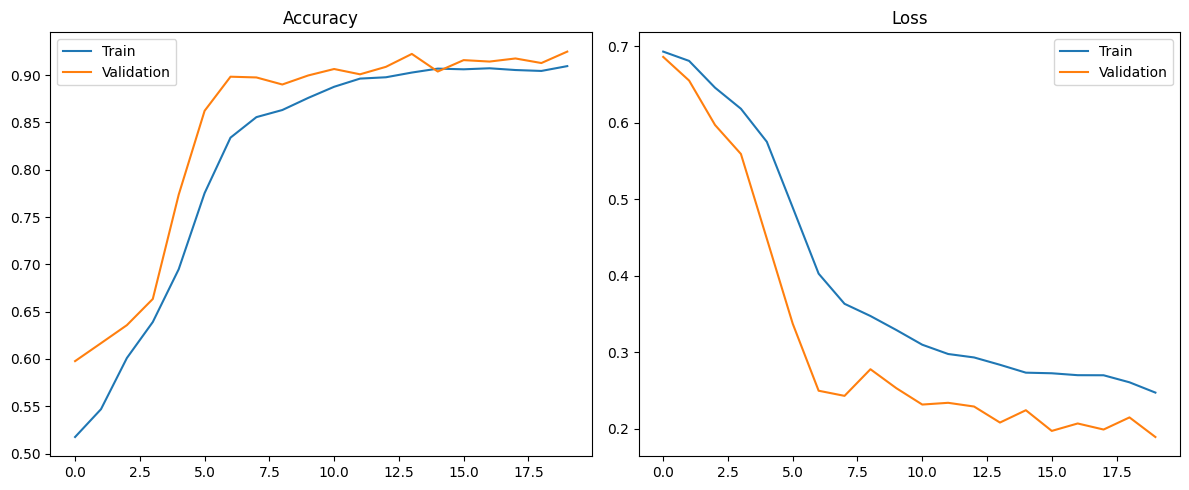

In [107]:
# =============================================================================
# CELL 7: PERFORMANCE METRICS & PLOTS
# =============================================================================
acc = accuracy_score(y_test, y_test_pred_binary)
print(f"Final Test Accuracy: {acc:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_test_pred_binary, digits=4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_binary))

roc_auc = roc_auc_score(y_test, y_test_pred_prob[:, 1])
print(f"\nROC-AUC Score: {roc_auc:.4f}")

# Plot training history
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [108]:
# =============================================================================
# CELL 8: PRIVACY BUDGET TRACKING (ε Estimation)
# =============================================================================
print("\n" + "="*70)
print("🔐 DIFFERENTIAL PRIVACY BUDGET ANALYSIS")
print("="*70)

# Parameters for accounting
n = X_train_scaled.shape[0]                    # Total training samples (before validation_split)
batch_size = best_hp['batch_size']
noise_multiplier = 1.3
epochs = best_hp['epochs']
delta = 1e-5                                   # Common target failure probability

print(f"Number of training examples (n)      : {n:,}")
print(f"Batch size                           : {batch_size}")
print(f"Noise multiplier                     : {noise_multiplier}")
print(f"Epochs                               : {epochs}")
print(f"Target delta (δ)                     : {delta}")
print(f"Approximate number of steps          : {int(n * epochs / batch_size):,}")
print("-" * 60)

# Compute ε (privacy budget)
epsilon, optimal_order = compute_dp_sgd_privacy(
    n=n,
    batch_size=batch_size,
    noise_multiplier=noise_multiplier,
    epochs=epochs,
    delta=delta
)

print(f"✅ Computed Privacy Guarantee:")
print(f"   ε  ≈ {epsilon:.4f}")
print(f"   at δ = {delta}")
print(f"   Optimal RDP order (α)            : {optimal_order:.2f}")

# Interpretation
if epsilon < 1.0:
    level = "Very Strong Privacy"
elif epsilon < 5.0:
    level = "Strong Privacy"
elif epsilon < 10.0:
    level = "Moderate Privacy"
else:
    level = "Weak Privacy (high ε - consider increasing noise_multiplier)"

print(f"   Interpretation                   : {level}")
print("\nNote:")
print("- Lower ε = stronger privacy protection.")
print("- Typical acceptable range in research: ε < 10 (ideally < 5).")
print("- This calculation assumes Poisson subsampling (standard for DP-SGD).")
print("- With num_microbatches=1, the actual privacy may be slightly stronger.")


🔐 DIFFERENTIAL PRIVACY BUDGET ANALYSIS
Number of training examples (n)      : 1,544,371
Batch size                           : 256
Noise multiplier                     : 1.3
Epochs                               : 20
Target delta (δ)                     : 1e-05
Approximate number of steps          : 120,653
------------------------------------------------------------
✅ Computed Privacy Guarantee:
   ε  ≈ 0.3043
   at δ = 1e-05
   Optimal RDP order (α)            : 28.00
   Interpretation                   : Very Strong Privacy

Note:
- Lower ε = stronger privacy protection.
- Typical acceptable range in research: ε < 10 (ideally < 5).
- This calculation assumes Poisson subsampling (standard for DP-SGD).
- With num_microbatches=1, the actual privacy may be slightly stronger.
